# Batch Aware Multisample Model

This model is an uses MMD to mitigate batch effect on multisample embeddings

In [35]:
import os
import numpy as np
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import importlib
import SpatialGlue
importlib.reload(SpatialGlue)

from SpatialGlue import SpatialGlueMini as Spatial
from SpatialGlue import train_model as train1

from SpatialGlueBatchAware import SpatialGlueMini, train_model
import random
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Helpers


In [36]:
# a KNN helper
def knn_edge_index(X, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, indices = nbrs.kneighbors(X)

    edges = []
    for i in range(X.shape[0]):
        for j in indices[i, 1:]:
            edges.append([i, j])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index

In [37]:
# helper to offset indices when merging graphs
def offset_edge_index(edge_index, offset):
    return edge_index + offset

# Data Preprocessing

Here we will load two different lymoh node samples and preprocess each sample to aquire both the spatil coordinates and features from each sample

In [38]:
# Load Data
adata_rna_A1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195494_A1_LN.h5ad")
adata_prot_A1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195498_A1_LN_Protein.h5ad")


adata_rna_D1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195496_D1_LN.h5ad")
adata_prot_D1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195500_D1_LN_Protein.h5ad")

In [39]:
# Align spots within each sample
common_A1 = adata_rna_A1.obs_names.intersection(adata_prot_A1.obs_names)
adata_rna_A1 = adata_rna_A1[common_A1].copy()
adata_prot_A1 = adata_prot_A1[common_A1].copy()
assert all(adata_rna_A1.obs_names == adata_prot_A1.obs_names)

common_D1 = adata_rna_D1.obs_names.intersection(adata_prot_D1.obs_names)
adata_rna_D1 = adata_rna_D1[common_D1].copy()
adata_prot_D1 = adata_prot_D1[common_D1].copy()
assert all(adata_rna_D1.obs_names == adata_prot_D1.obs_names)

In [40]:
# Extract processed features and coordinates
X_rna_A1 = adata_rna_A1.obsm["feat"].astype(np.float32)
X_prot_A1 = adata_prot_A1.obsm["feat"].astype(np.float32)
coords_A1 = adata_rna_A1.obsm["spatial"].astype(np.float32)

X_rna_D1 = adata_rna_D1.obsm["feat"].astype(np.float32)
X_prot_D1 = adata_prot_D1.obsm["feat"].astype(np.float32)
coords_D1 = adata_rna_D1.obsm["spatial"].astype(np.float32)

print("A1 RNA:", X_rna_A1.shape)
print("A1 Protein:", X_prot_A1.shape)
print("A1 coords:", coords_A1.shape)

print("D1 RNA:", X_rna_D1.shape)
print("D1 Protein:", X_prot_D1.shape)
print("D1 coords:", coords_D1.shape)

#Create Sample Labels
sample_ids_A1 = np.zeros(X_rna_A1.shape[0], dtype=np.int64)
sample_ids_D1 = np.ones(X_rna_D1.shape[0], dtype=np.int64)

sample_names = (
    ["A1_LN"] * X_rna_A1.shape[0] +
    ["D1_LN"] * X_rna_D1.shape[0]
)
sample_names = np.array(sample_names)

A1 RNA: (3484, 30)
A1 Protein: (3484, 30)
A1 coords: (3484, 2)
D1 RNA: (3359, 30)
D1 Protein: (3359, 30)
D1 coords: (3359, 2)


C:\Users\imoha\AppData\Local\Temp\ipykernel_7508\1604311408.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_rna_A1, spot_size=1)


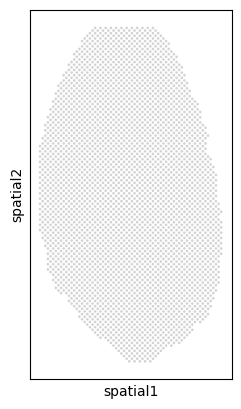

C:\Users\imoha\AppData\Local\Temp\ipykernel_7508\1604311408.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_rna_D1, spot_size=1)


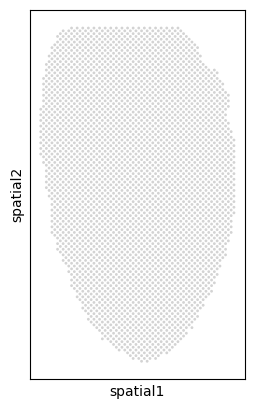

In [77]:
adata_rna_A1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195494_A1_LN.h5ad")
#adata_prot_A1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195498_A1_LN_Protein.h5ad")

adata_rna_D1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195496_D1_LN.h5ad")

sc.pl.spatial(adata_rna_A1, spot_size=1)

sc.pl.spatial(adata_rna_D1, spot_size=1)

In [41]:
#Combine features for future plotting
X_rna_all = np.concatenate([X_rna_A1, X_rna_D1], axis=0)
X_prot_all = np.concatenate([X_prot_A1, X_prot_D1], axis=0)
sample_ids = np.concatenate([sample_ids_A1, sample_ids_D1], axis=0)

print("Combined RNA:", X_rna_all.shape)
print("Combined Protein:", X_prot_all.shape)
print("Combined sample_ids:", sample_ids.shape)

Combined RNA: (6843, 30)
Combined Protein: (6843, 30)
Combined sample_ids: (6843,)


# Building Graphs for each smaple

In [42]:
# Spatial graphs
spatial_A1 = knn_edge_index(coords_A1, k=3)
spatial_D1 = knn_edge_index(coords_D1, k=3)

In [43]:
# Feature graphs
rna_feat_A1 = knn_edge_index(X_rna_A1, k=20)
rna_feat_D1 = knn_edge_index(X_rna_D1, k=20)

prot_feat_A1 = knn_edge_index(X_prot_A1, k=20)
prot_feat_D1 = knn_edge_index(X_prot_D1, k=20)

In [44]:
# Merged graphs as DISCONNECTED components
# If sample A1 has N1 spots, then every node index in D1 must be shifted by N1

N1 = X_rna_A1.shape[0]
N2 = X_rna_D1.shape[0]

spatial_D1_off = offset_edge_index(spatial_D1, N1)
rna_feat_D1_off = offset_edge_index(rna_feat_D1, N1)
prot_feat_D1_off = offset_edge_index(prot_feat_D1, N1)

spatial_edge_index = torch.cat([spatial_A1, spatial_D1_off], dim=1)
rna_feature_edge_index = torch.cat([rna_feat_A1, rna_feat_D1_off], dim=1)
prot_feature_edge_index = torch.cat([prot_feat_A1, prot_feat_D1_off], dim=1)

print("Merged spatial graph:", spatial_edge_index.shape)
print("Merged RNA feature graph:", rna_feature_edge_index.shape)
print("Merged protein feature graph:", prot_feature_edge_index.shape)

Merged spatial graph: torch.Size([2, 20529])
Merged RNA feature graph: torch.Size([2, 136860])
Merged protein feature graph: torch.Size([2, 136860])


# Train models

In [45]:
# Convert features into tensors
X_rna_t = torch.tensor(X_rna_all, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot_all, dtype=torch.float32)
sample_ids_t = torch.tensor(sample_ids, dtype=torch.long)

### NO batch Model

In [ ]:
model_no_batch = SpatialGlueMini(
    in_dim=30,
    hidden_dim=64,
    latent_dim=32,
    num_modalities=2,
    dropout=0.1
)

model_no_batch = train_model(
    model_no_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=None,
    epochs=1000,
    lr=1e-3,
    lambda_corr=1.0,
    lambda_batch=0.0,
    device="cpu"
)

Epoch 0000 | total=9.1439 | recon=7.1524 | corr=1.9915 | batch=0.0000
Epoch 0050 | total=3.9751 | recon=3.8615 | corr=0.1136 | batch=0.0000
Epoch 0100 | total=3.5927 | recon=3.5050 | corr=0.0877 | batch=0.0000
Epoch 0150 | total=3.4382 | recon=3.3637 | corr=0.0745 | batch=0.0000
Epoch 0200 | total=3.3031 | recon=3.2355 | corr=0.0676 | batch=0.0000
Epoch 0250 | total=3.3562 | recon=3.2888 | corr=0.0674 | batch=0.0000
Epoch 0300 | total=3.2386 | recon=3.1708 | corr=0.0678 | batch=0.0000
Epoch 0350 | total=3.1682 | recon=3.0999 | corr=0.0684 | batch=0.0000
Epoch 0400 | total=3.1376 | recon=3.0773 | corr=0.0603 | batch=0.0000
Epoch 0450 | total=2.9887 | recon=2.9314 | corr=0.0573 | batch=0.0000
Epoch 0500 | total=2.9432 | recon=2.8876 | corr=0.0557 | batch=0.0000
Epoch 0550 | total=2.9614 | recon=2.9121 | corr=0.0493 | batch=0.0000
Epoch 0600 | total=2.8476 | recon=2.7988 | corr=0.0488 | batch=0.0000
Epoch 0650 | total=2.8263 | recon=2.7791 | corr=0.0472 | batch=0.0000
Epoch 0700 | total=2

In [65]:
model_no_batch.eval()
with torch.no_grad():
    outputs_no_batch = model_no_batch(
        [X_rna_t, X_prot_t],
        spatial_edge_index,
        [rna_feature_edge_index, prot_feature_edge_index]
    )

Z_no_batch = outputs_no_batch["z"].cpu().numpy()

### Batch Aware Model

In [67]:
model_batch = SpatialGlueMini(
    in_dim=30,
    hidden_dim=64,
    latent_dim=32,
    num_modalities=2,
    dropout=0.1
)

model_batch = train_model(
    model_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=sample_ids_t,
    epochs=1000,
    lr=1e-3,
    lambda_corr=1.0,
    lambda_batch=0.1,
    device="cpu"
)

Epoch 0000 | total=10.0235 | recon=7.2198 | corr=2.8031 | batch=0.0065
Epoch 0050 | total=6.3917 | recon=5.9175 | corr=0.4727 | batch=0.0145
Epoch 0100 | total=4.9625 | recon=4.5674 | corr=0.3934 | batch=0.0164
Epoch 0150 | total=4.4419 | recon=4.1381 | corr=0.3020 | batch=0.0188
Epoch 0200 | total=4.1926 | recon=3.9504 | corr=0.2401 | batch=0.0205
Epoch 0250 | total=4.0212 | recon=3.8137 | corr=0.2052 | batch=0.0228
Epoch 0300 | total=3.9047 | recon=3.7234 | corr=0.1788 | batch=0.0248
Epoch 0350 | total=3.8108 | recon=3.6478 | corr=0.1604 | batch=0.0260
Epoch 0400 | total=3.7206 | recon=3.5704 | corr=0.1473 | batch=0.0289
Epoch 0450 | total=3.6535 | recon=3.5131 | corr=0.1375 | batch=0.0288
Epoch 0500 | total=3.5962 | recon=3.4658 | corr=0.1273 | batch=0.0313
Epoch 0550 | total=3.5517 | recon=3.4303 | corr=0.1183 | batch=0.0312
Epoch 0600 | total=3.5054 | recon=3.3909 | corr=0.1111 | batch=0.0335
Epoch 0650 | total=3.4659 | recon=3.3582 | corr=0.1043 | batch=0.0337
Epoch 0700 | total=

In [68]:
model_batch.eval()
with torch.no_grad():
    outputs_batch = model_batch(
        [X_rna_t, X_prot_t],
        spatial_edge_index,
        [rna_feature_edge_index, prot_feature_edge_index]
    )

Z_batch = outputs_batch["z"].cpu().numpy()

# Results

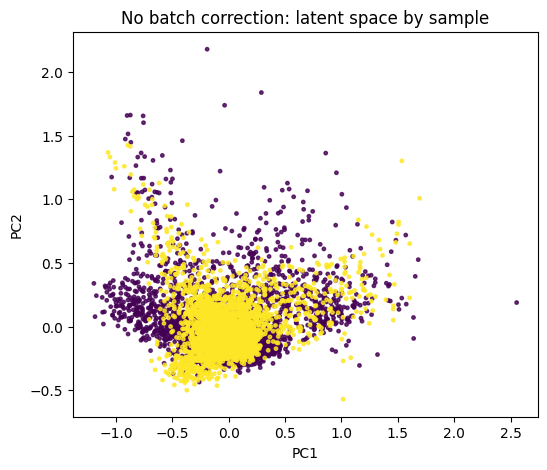

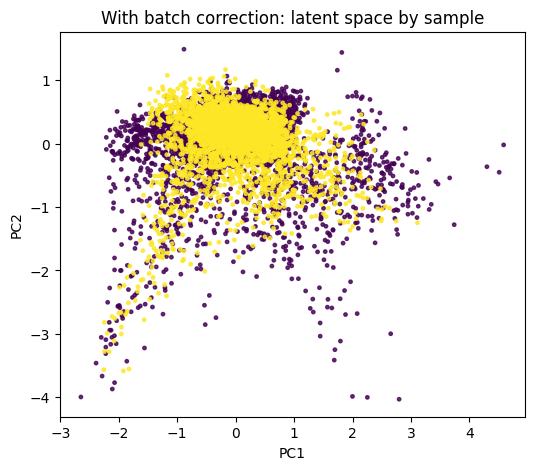

In [69]:
from sklearn.decomposition import PCA

os.makedirs("outputs/stage3/figures", exist_ok=True)

pca = PCA(n_components=2)

Z2_no_batch = pca.fit_transform(Z_no_batch)
Z2_batch = pca.fit_transform(Z_batch)

plt.figure(figsize=(6, 5))
plt.scatter(Z2_no_batch[:, 0], Z2_no_batch[:, 1], c=sample_ids, s=6, alpha=0.8)
plt.title("No batch correction: latent space by sample")
plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.savefig("outputs/stage3/figures/NoBatch_LatentSpace.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(Z2_batch[:, 0], Z2_batch[:, 1], c=sample_ids, s=6, alpha=0.8)
plt.title("With batch correction: latent space by sample")
plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.savefig("outputs/stage3/figures/Batch_LatentSpace.png", dpi=300)

plt.show()

# Ensure Spatial Structure is Preserved

In [51]:
from sklearn.cluster import KMeans

labels_no_batch = KMeans(n_clusters=10, random_state=0).fit_predict(Z_no_batch)

labels_A1_no_batch = labels_no_batch[:N1]
labels_D1_no_batch = labels_no_batch[N1:]

In [52]:
labels_batch = KMeans(n_clusters=10, random_state=0).fit_predict(Z_batch)

labels_A1_batch = labels_batch[:N1]
labels_D1_batch = labels_batch[N1:]

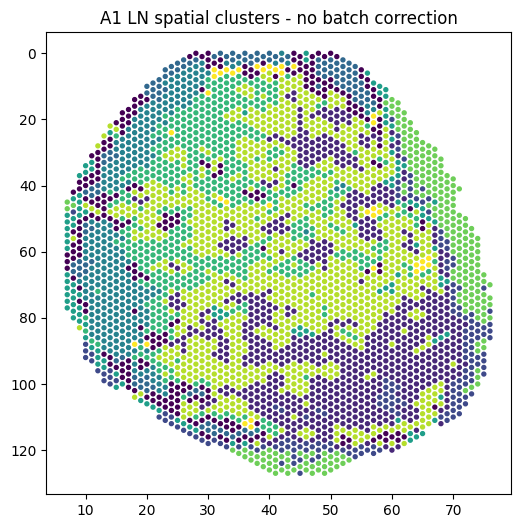

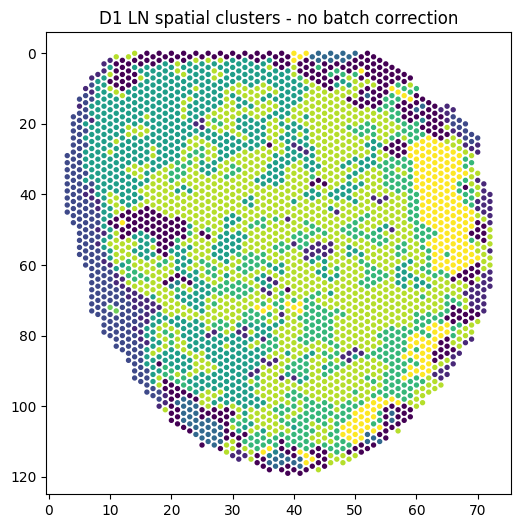

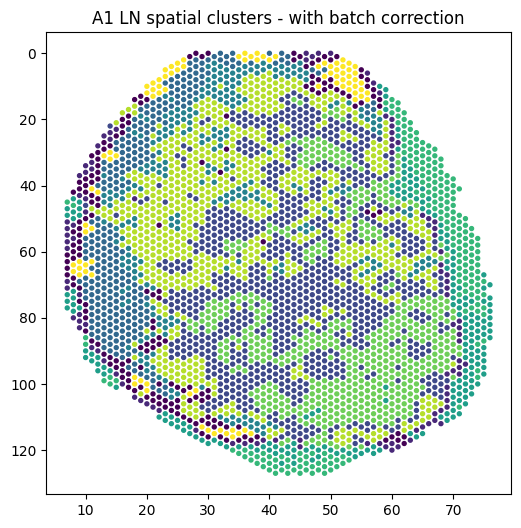

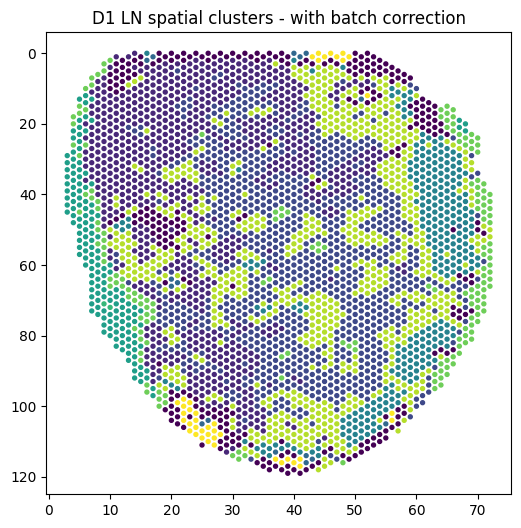

In [57]:
plt.figure(figsize=(6, 6))
plt.scatter(coords_A1[:, 0], coords_A1[:, 1], c=labels_A1_no_batch, s=8)
plt.gca().invert_yaxis()
plt.title("A1 LN spatial clusters - no batch correction")
plt.savefig("outputs/stage3/figures/NoBatch_D1_LN_Cluster.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(coords_D1[:, 0], coords_D1[:, 1], c=labels_D1_no_batch, s=8)
plt.gca().invert_yaxis()
plt.title("D1 LN spatial clusters - no batch correction")
plt.savefig("outputs/stage3/figures/NoBatch_D1_LN_Cluster.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(coords_A1[:, 0], coords_A1[:, 1], c=labels_A1_batch, s=8)
plt.gca().invert_yaxis()
plt.title("A1 LN spatial clusters - with batch correction")
plt.savefig("outputs/stage3/figures/NoBatch_A1_LN_Cluster.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(coords_D1[:, 0], coords_D1[:, 1], c=labels_D1_batch, s=8)
plt.gca().invert_yaxis()
plt.title("D1 LN spatial clusters - with batch correction")
plt.savefig("outputs/stage3/figures/Batch_D1_LN_Cluster.png", dpi=300)
plt.show()

In [56]:
os.makedirs("outputs/stage3/figures", exist_ok=True)
os.makedirs("outputs/stage3/model", exist_ok=True)
os.makedirs("outputs/stage3/embeddings", exist_ok=True)


np.save("outputs/stage3/embeddings/Z_no_batch_A1_D1_LN.npy", Z_no_batch)
np.save("outputs/stage3/embeddings/Z_batch_A1_D1_LN.npy", Z_batch)

np.save("outputs/stage3/embeddings/labels_no_batch_A1_D1_LN.npy", labels_no_batch)
np.save("outputs/stage3/embeddings/labels_batch_A1_D1_LN.npy", labels_batch)

torch.save(model_no_batch.state_dict(), "outputs/stage3/model/model_no_batch_A1_D1_LN.pt")
torch.save(model_batch.state_dict(), "outputs/stage3/model/model_batch_A1_D1_LN.pt")